In [1]:
import ee
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL
from IPython.display import display, Markdown

In [2]:
organisation = "rotterdam"
auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

monitoring well: 100%|██████████| 13/13 [00:22<00:00,  1.71s/it]


In [4]:
project = 'afstuderen-481613'

try:
    ee.Initialize(project=project)
except:
    ee.Authenticate()
    ee.Initialize(project=project)

roi = ee.Geometry.Rectangle(extent_to_ee("ndvi"))

In [6]:
# Retrieve KNMI meteorological data
gw = oc.obs["GMW000000037950001"] # GMW000000046935001   # GMW000000038241001

# Filter on date range (use NDVI date range for consistency)
tmin = datetime.datetime.strptime(NDVI_START_DATE, "%Y-%m-%d").date()
tmax = datetime.datetime.strptime(NDVI_END_DATE, "%Y-%m-%d").date()

precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw.x, gw.y),
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw.x, gw.y),
    meteo_var="EV24",
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)

print("Meteorological data retrieved from KNMI")
print(f"Precipitation: {len(precipitation)} records")
print(f"Evaporation: {len(evaporation)} records")

Meteorological data retrieved from KNMI
Precipitation: 1736 records
Evaporation: 1736 records


c:\Users\odin0\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


<Axes: title={'center': 'meteo observations'}, ylabel='m/dag'>

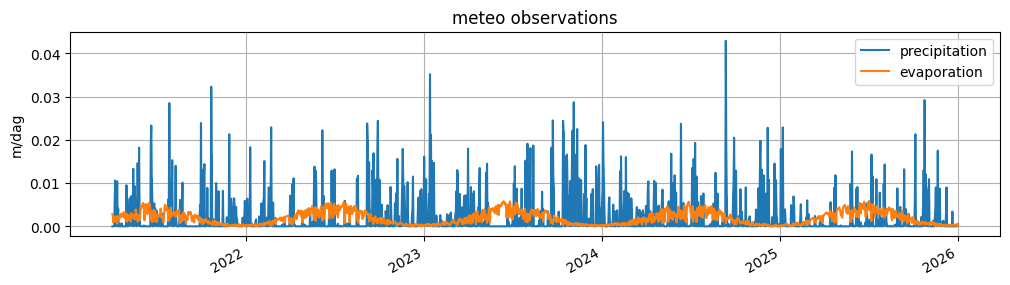

In [7]:
# --- Plot as spikes (like rainfall graphs) ---
fig, ax = plt.subplots(figsize=(12, 3))

# precipitation as vertical lines
ax.vlines(
    precipitation.index,
    ymin=0,
    ymax=precipitation["RH"],
    linewidth=0.6,
    label="precipitation",
)

ax = precipitation["RH"].plot(label="precipitation", legend=True, figsize=(12, 3))
evaporation["EV24"].plot(
    ax=ax,
    label="evaporation",
    legend=True,
    grid=True,
    ylabel="m/dag",
    title="meteo observations",
)

In [8]:
# ---------- helpers ----------
def ee_fc_to_df(fc, props=("date", "ndvi", "n_pixels")):
    feats = fc.getInfo()["features"]
    rows = []
    for f in feats:
        p = f.get("properties", {})
        if all(p.get(k) is not None for k in props):
            rows.append({k: p.get(k) for k in props})
    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df["ndvi"] = df["ndvi"].astype(float)
        df["n_pixels"] = df["n_pixels"].astype(float)
        df = df.sort_values("date").reset_index(drop=True)
    return df


def reduce_ndvi_mean_and_count(img, roi, scale):
    stats = img.select("NDVI").reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
        geometry=roi,
        scale=scale,
        bestEffort=True,
        maxPixels=1e13,
    )
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")
    return ee.Feature(None, {
        "date": date,
        "ndvi": stats.get("NDVI_mean"),
        "n_pixels": stats.get("NDVI_count"),
    })


def ndvi_timeseries(collection_id, roi, start_date, end_date, scale,
                    add_ndvi_fn, mask_fn=None, extra_filter=None):

    col = (ee.ImageCollection(collection_id)
           .filterBounds(roi)
           .filterDate(start_date, end_date))

    if extra_filter is not None:
        col = col.filter(extra_filter)
    if mask_fn is not None:
        col = col.map(mask_fn)

    col = col.map(add_ndvi_fn)

    fc = col.map(lambda img: reduce_ndvi_mean_and_count(img, roi, scale))
    df = ee_fc_to_df(ee.FeatureCollection(fc))
    return df


# ---------- Sentinel-2 specifics ----------
def mask_s2_clouds(img):
    scl = img.select("SCL")
    mask = (scl.neq(3)
            .And(scl.neq(7))
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return img.updateMask(mask)


def add_ndvi_s2(img):
    return img.addBands(img.normalizedDifference(["B8", "B4"]).rename("NDVI"))


# ---------- Run Sentinel‑2 only ----------
df_s2 = ndvi_timeseries(
    collection_id="COPERNICUS/S2_SR_HARMONIZED",
    roi=roi,
    start_date=NDVI_START_DATE,
    end_date=NDVI_END_DATE,
    scale=10,
    add_ndvi_fn=add_ndvi_s2,
    mask_fn=mask_s2_clouds,
    extra_filter=ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30),
)

df_s2

,date,ndvi,n_pixels
0,2021-04-20,0.234137,9200.0
1,2021-04-20,0.215804,8952.0
2,2021-05-30,0.371312,12287.0
3,2021-05-30,0.359196,11792.0
4,2021-06-09,0.349162,12287.0
...,...,...,...
121,2025-09-01,0.429951,1390.0
122,2025-12-25,0.260926,12243.0
123,2025-12-25,0.273917,11784.0
124,2025-12-30,0.305327,12223.0


,count
status,
kept,94
removed,32


,date,ndvi,n_pixels
0,2021-08-03,0.320993,1307.0
1,2021-08-23,0.467257,2978.0
2,2021-12-16,0.434511,7834.0
3,2021-12-16,0.311453,8234.0
4,2022-06-09,0.456628,3769.0
5,2022-07-04,0.540499,569.0
6,2022-07-24,0.392412,6833.0
7,2022-07-24,0.369805,6613.0
8,2022-08-18,0.505655,28.0
9,2023-04-30,0.310837,972.0


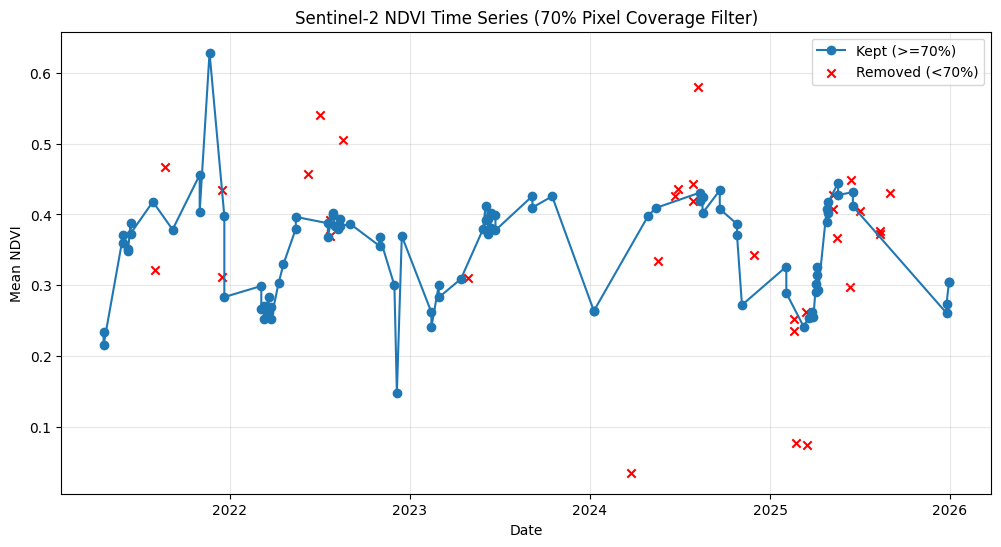

In [9]:
# Compute expected number of 10m pixels in ROI
roi_area_m2 = roi.area().getInfo()
pixel_area = 10 * 10
expected_pixels = roi_area_m2 / pixel_area

# 70% threshold
threshold = expected_pixels * 0.70

# Apply threshold
df = df_s2.copy()
df["min_required"] = threshold
df["status"] = np.where(df["n_pixels"] >= df["min_required"], "kept", "removed")

df_kept = df[df["status"] == "kept"].reset_index(drop=True)
df_removed = df[df["status"] == "removed"].reset_index(drop=True)

# Summary
summary = df.groupby("status").size().to_frame("count")
display(summary)

# Show removed rows
display(df_removed[["date", "ndvi", "n_pixels"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_kept["date"], df_kept["ndvi"], marker="o", label="Kept (>=70%)")

if len(df_removed) > 0:
    plt.scatter(df_removed["date"], df_removed["ndvi"], marker="x", color="red", label="Removed (<70%)")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.title("Sentinel‑2 NDVI Time Series (70% Pixel Coverage Filter)")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ================================
# Monthly aggregation (after pixel coverage filter)
# ================================

# NDVI: use only the kept pixels (>=70% coverage) and filter by date range,
# then aggregate to monthly mean
df_s2_filtered = df_kept[
    (df_kept["date"] >= NDVI_START_DATE) & 
    (df_kept["date"] <= NDVI_END_DATE)
].copy()

df_s2_copy = df_s2_filtered.copy()
df_s2_copy["year_month"] = df_s2_copy["date"].dt.to_period("M")
df_s2_month = df_s2_copy.groupby("year_month").agg({
    "ndvi": "mean",
    "date": "first"
}).reset_index(drop=True)
df_s2_month = df_s2_month.rename(columns={"ndvi": "ndvi_month"})
print(f"NDVI data filtered (after pixel coverage): {len(df_kept)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} months)")
print(f"NDVI data filtered: {len(df_s2)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} months)")

# Meteorological data: aggregate to monthly mean
# Daily recharge = precipitation - evaporation
P_daily = precipitation["RH"].resample("D").sum()
E_daily = evaporation["EV24"].resample("D").sum()
recharge_daily = P_daily - E_daily  # already in mm

# Monthly aggregation
meteo_df = pd.DataFrame({
    'date': P_daily.index,
    'P': P_daily.values,
    'E': E_daily.values,
    'recharge': recharge_daily.values
})
meteo_df['year_month'] = pd.to_datetime(meteo_df['date']).dt.to_period('M')

meteo_month = meteo_df.groupby('year_month').agg({
    'P': 'sum',
    'E': 'sum',
    'recharge': 'sum',
    'date': 'first'
}).reset_index(drop=True)
meteo_month = meteo_month.rename(columns={'recharge': 'recharge_month', 'P': 'P_month', 'E': 'E_month'})

print(f"Meteo data aggregated to {len(meteo_month)} months")

display(df_s2_month.head())
display(meteo_month.head())

NDVI data filtered (after pixel coverage): 94 -> 94 records (35 months)
NDVI data filtered: 126 -> 94 records (35 months)
Meteo data aggregated to 57 months


,ndvi_month,date
0,0.224971,2021-04-20
1,0.365254,2021-05-30
2,0.365678,2021-06-09
3,0.417993,2021-07-29
4,0.378673,2021-09-07


,P_month,E_month,recharge_month,date
0,0.0500,0.0638,-0.0138,2021-04-01
1,0.1192,0.0737,0.0455,2021-05-01
2,0.0724,0.1094,-0.0370,2021-06-01
3,0.0744,0.0871,-0.0127,2021-07-01
4,0.0728,0.0790,-0.0062,2021-08-01


In [11]:
# --- Groundwater: maandgemiddelde per maand ---
gw_filtered = gw[(gw.index >= NDVI_START_DATE) & (gw.index <= NDVI_END_DATE)].copy()
gw_month_df = gw_filtered.reset_index()
gw_month_df.columns = ["peil_datum_tijd", "peil_waarde_cm", "flag", "comment", "origin"]
gw_month_df["peil_datum_tijd"] = pd.to_datetime(gw_month_df["peil_datum_tijd"])
gw_month_df["year_month"] = gw_month_df["peil_datum_tijd"].dt.to_period("M")
gw_month = gw_month_df.groupby("year_month").agg({
    "peil_waarde_cm": "mean",
    "peil_datum_tijd": "first"
}).reset_index(drop=True)
gw_month = gw_month.rename(columns={"peil_waarde_cm": "gw_month"})
gw_month["date"] = pd.to_datetime(gw_month["peil_datum_tijd"])


In [12]:
# =============================================================================
# CLEAN & ROBUST MERGE + INTERPOLATION – datetime-safe version
# =============================================================================

import pandas as pd

# ────────────────────────────────────────────────
# 1. Standardize ALL input dataframes to have real datetime 'date'
# ────────────────────────────────────────────────
for name, df in [
    ("NDVI (df_s2_month)", df_s2_month),
    ("Meteo (meteo_month)", meteo_month),
    ("GW (gw_month)", gw_month)
]:
    if "date_period" in df.columns:
        # Convert period → timestamp (first of month)
        df["date"] = df["date_period"].dt.to_timestamp()
        print(f"{name}: converted date_period → date (datetime)")
    
    if "date" in df.columns:
        # Force to datetime if it isn't already
        df["date"] = pd.to_datetime(df["date"])
    
    # Optional: drop period column to avoid confusion later
    if "date_period" in df.columns:
        df = df.drop(columns=["date_period"])

# ────────────────────────────────────────────────
# 2. Merge – only on 'date' now (safer)
# ────────────────────────────────────────────────
df_month = (
    df_s2_month[["date", "ndvi_month"]]
    .merge(
        meteo_month[["date", "P_month", "E_month", "recharge_month"]],
        on="date",
        how="outer",
        suffixes=("_ndvi", "_meteo")
    )
    .merge(
        gw_month[["date", "gw_month"]],
        on="date",
        how="outer"
    )
)

# Make sure 'date' is datetime (in case outer merge introduced NaT)
df_month["date"] = pd.to_datetime(df_month["date"])

# Sort and reset
df_month = df_month.sort_values("date").reset_index(drop=True)

# ────────────────────────────────────────────────
# 3. Interpolation + flags
# ────────────────────────────────────────────────
df_month["ndvi_interpolated"]     = df_month["ndvi_month"].isna()
df_month["recharge_interpolated"] = df_month["recharge_month"].isna()
df_month["gw_interpolated"]       = df_month["gw_month"].isna()

for col in ["ndvi_month", "recharge_month", "gw_month"]:
    df_month[col] = df_month[col].interpolate(method="linear", limit_direction="both")

# Drop rows where **all three** variables are still NaN (edge cases)
df_month = df_month.dropna(
    subset=["ndvi_month", "recharge_month", "gw_month"],
    how="all"
).reset_index(drop=True)

# ────────────────────────────────────────────────
# 4. Diagnostics – now safe because 'date' is datetime
# ────────────────────────────────────────────────
print(f"\n--- Final monthly dataframe ready for modelling ---")
print(f"Shape: {df_month.shape}")
print(f"Date range: {df_month['date'].min().date()} → {df_month['date'].max().date()}")
print(f"Months: {len(df_month)}")
print(f"NDVI interpolated: {df_month['ndvi_interpolated'].sum()} / {len(df_month)}")
print(f"Recharge interpolated: {df_month['recharge_interpolated'].sum()} / {len(df_month)}")
print(f"GW interpolated: {df_month['gw_interpolated'].sum()} / {len(df_month)}")

# Quick look
display(df_month.head(8)[["date", "ndvi_month", "recharge_month", "gw_month", 
                         "ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]])
display(df_month.tail(8)[["date", "ndvi_month", "recharge_month", "gw_month", 
                         "ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]])


--- Final monthly dataframe ready for modelling ---
Shape: (145, 9)
Date range: 2021-04-01 → 2025-12-25
Months: 145
NDVI interpolated: 110 / 145
Recharge interpolated: 88 / 145
GW interpolated: 88 / 145


,date,ndvi_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
0,2021-04-01 00:00:00,0.224971,-0.013800,-2.63,True,False,True
1,2021-04-14 07:36:00,0.224971,0.005967,-2.63,True,True,False
2,2021-04-20 00:00:00,0.224971,0.025733,-2.62,False,True,True
3,2021-05-01 00:00:00,0.271732,0.045500,-2.61,True,False,True
4,2021-05-10 06:16:00,0.318493,0.018000,-2.60,True,True,False
5,2021-05-30 00:00:00,0.365254,-0.009500,-2.61,False,True,True
6,2021-06-01 00:00:00,0.365395,-0.037000,-2.62,True,False,True
7,2021-06-02 08:28:00,0.365536,-0.028900,-2.63,True,True,False


,date,ndvi_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
137,2025-09-01 01:05:07,0.359142,0.0381,-2.956056,True,True,False
138,2025-10-01 00:00:00,0.348747,0.0959,-2.910735,True,False,True
139,2025-10-01 05:10:04,0.338352,0.0762,-2.865413,True,True,False
140,2025-11-01 00:00:00,0.327957,0.0565,-2.816538,True,False,True
141,2025-11-01 13:15:18,0.317562,0.0340,-2.767662,True,True,False
142,2025-12-01 00:00:00,0.307168,0.0115,-2.772831,True,False,True
143,2025-12-01 05:20:28,0.296773,0.0115,-2.778000,True,True,False
144,2025-12-25 00:00:00,0.286378,0.0115,-2.778000,False,True,True


In [13]:
# Track interpolatie voor alle kolommen

df_month["ndvi_interpolated"] = df_month["ndvi_month"].isna()

df_month["recharge_interpolated"] = df_month["recharge_month"].isna()

df_month["gw_interpolated"] = df_month["gw_month"].isna()



print(f"\n--- Data beschikbaarheid ---")

print(f"Werkelijke maanden in analyse: {len(df_month)}")

print(f"NDVI geïnterpoleerd: {df_month['ndvi_interpolated'].sum()} keer")

print(f"Recharge geïnterpoleerd: {df_month['recharge_interpolated'].sum()} keer")

print(f"GW geïnterpoleerd: {df_month['gw_interpolated'].sum()} keer")



display(df_month[["date", "ndvi_month", "recharge_month", "gw_month", "ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]])



--- Data beschikbaarheid ---
Werkelijke maanden in analyse: 145
NDVI geïnterpoleerd: 0 keer
Recharge geïnterpoleerd: 0 keer
GW geïnterpoleerd: 0 keer


,date,ndvi_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
0,2021-04-01 00:00:00,0.224971,-0.013800,-2.630000,False,False,False
1,2021-04-14 07:36:00,0.224971,0.005967,-2.630000,False,False,False
2,2021-04-20 00:00:00,0.224971,0.025733,-2.620000,False,False,False
3,2021-05-01 00:00:00,0.271732,0.045500,-2.610000,False,False,False
4,2021-05-10 06:16:00,0.318493,0.018000,-2.600000,False,False,False
...,...,...,...,...,...,...,...
140,2025-11-01 00:00:00,0.327957,0.056500,-2.816538,False,False,False
141,2025-11-01 13:15:18,0.317562,0.034000,-2.767662,False,False,False
142,2025-12-01 00:00:00,0.307168,0.011500,-2.772831,False,False,False
143,2025-12-01 05:20:28,0.296773,0.011500,-2.778000,False,False,False


In [14]:
# Track interpolatie voor alle kolommen
df_month["ndvi_interpolated"] = df_month["ndvi_month"].isna()
df_month["recharge_interpolated"] = df_month["recharge_month"].isna()
df_month["gw_interpolated"] = df_month["gw_month"].isna()

# Interpoleer alle kolommen
df_month["ndvi_month"] = df_month["ndvi_month"].interpolate(method="linear")
df_month["recharge_month"] = df_month["recharge_month"].interpolate(method="linear")
df_month["gw_month"] = df_month["gw_month"].interpolate(method="linear")

# Verwijder alleen de edges met NaN
df_month = df_month.dropna(subset=["ndvi_month", "recharge_month", "gw_month"]).reset_index(drop=True)


In [15]:
# =============================================================================
# FIXED MERGE: NDVI + Meteo + GW — join on datetime 'date' (not period)
# =============================================================================

# Step 1: Make sure EVERY dataframe has a clean datetime 'date' column
for name, df in [
    ("df_s2_month (NDVI)", df_s2_month),
    ("meteo_month", meteo_month),
    ("gw_month", gw_month)
]:
    # If it has a period column, convert → timestamp
    period_col = None
    for possible in ["date_period", "year_month", "period"]:
        if possible in df.columns:
            period_col = possible
            break
    
    if period_col is not None:
        df["date"] = df[period_col].dt.to_timestamp()
        print(f"{name}: converted {period_col} → date (datetime)")
        # Optional: drop the period column to clean up
        # df = df.drop(columns=[period_col])
    
    # Force 'date' to be datetime if it exists but isn't
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Step 2: Merge on 'date' (outer = keep all months even if missing in one source)
df_month = (
    df_s2_month[["date", "ndvi_month"]]
    .merge(
        meteo_month[["date", "P_month", "E_month", "recharge_month"]],
        on="date",
        how="outer"
    )
    .merge(
        gw_month[["date", "gw_month"]],
        on="date",
        how="outer"
    )
)

# Clean up: sort + reset
df_month = df_month.sort_values("date").reset_index(drop=True)

# Step 3: Interpolation + flags (linear inside the series)
df_month["ndvi_interpolated"]     = df_month["ndvi_month"].isna()
df_month["recharge_interpolated"] = df_month["recharge_month"].isna()
df_month["gw_interpolated"]       = df_month["gw_month"].isna()

for col in ["ndvi_month", "recharge_month", "gw_month"]:
    df_month[col] = df_month[col].interpolate(method="linear", limit_direction="both")

# Drop completely empty rows at edges if desired
df_month = df_month.dropna(subset=["ndvi_month", "recharge_month", "gw_month"], how="all").reset_index(drop=True)

# =============================================================================
# Diagnostic output — check if everything looks correct
# =============================================================================
print(f"Final df_month shape: {df_month.shape}")
print(f"Date range: {df_month['date'].min().date()} → {df_month['date'].max().date()}")
print(f"Months total: {len(df_month)}")
print(f"NDVI interpolated: {df_month['ndvi_interpolated'].sum()}")
print(f"Recharge interpolated: {df_month['recharge_interpolated'].sum()}")
print(f"GW interpolated: {df_month['gw_interpolated'].sum()}")

# Preview — should show clean dates and reasonable values
display(df_month.head(10))
display(df_month.tail(6))

Final df_month shape: (145, 9)
Date range: 2021-04-01 → 2025-12-25
Months total: 145
NDVI interpolated: 110
Recharge interpolated: 88
GW interpolated: 88


,date,ndvi_month,P_month,E_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
0,2021-04-01 00:00:00,0.224971,0.0500,0.0638,-0.013800,-2.630000,True,False,True
1,2021-04-14 07:36:00,0.224971,NaN,NaN,0.005967,-2.630000,True,True,False
2,2021-04-20 00:00:00,0.224971,NaN,NaN,0.025733,-2.620000,False,True,True
3,2021-05-01 00:00:00,0.271732,0.1192,0.0737,0.045500,-2.610000,True,False,True
4,2021-05-10 06:16:00,0.318493,NaN,NaN,0.018000,-2.600000,True,True,False
5,2021-05-30 00:00:00,0.365254,NaN,NaN,-0.009500,-2.610000,False,True,True
6,2021-06-01 00:00:00,0.365395,0.0724,0.1094,-0.037000,-2.620000,True,False,True
7,2021-06-02 08:28:00,0.365536,NaN,NaN,-0.028900,-2.630000,True,True,False
8,2021-06-09 00:00:00,0.365678,NaN,NaN,-0.020800,-2.663333,False,True,True
9,2021-07-01 00:00:00,0.383116,0.0744,0.0871,-0.012700,-2.696667,True,False,True


,date,ndvi_month,P_month,E_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
139,2025-10-01 05:10:04,0.338352,NaN,NaN,0.0762,-2.865413,True,True,False
140,2025-11-01 00:00:00,0.327957,0.0702,0.0137,0.0565,-2.816538,True,False,True
141,2025-11-01 13:15:18,0.317562,NaN,NaN,0.0340,-2.767662,True,True,False
142,2025-12-01 00:00:00,0.307168,0.0196,0.0081,0.0115,-2.772831,True,False,True
143,2025-12-01 05:20:28,0.296773,NaN,NaN,0.0115,-2.778000,True,True,False
144,2025-12-25 00:00:00,0.286378,NaN,NaN,0.0115,-2.778000,False,True,True



OLS LINEAIRE REGRESSIE RESULTATEN (NDVI ~ GW + Recharge)
                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     14.41
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.00e-06
Time:                        00:38:09   Log-Likelihood:                 221.39
No. Observations:                 145   AIC:                            -436.8
Df Residuals:                     142   BIC:                            -427.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

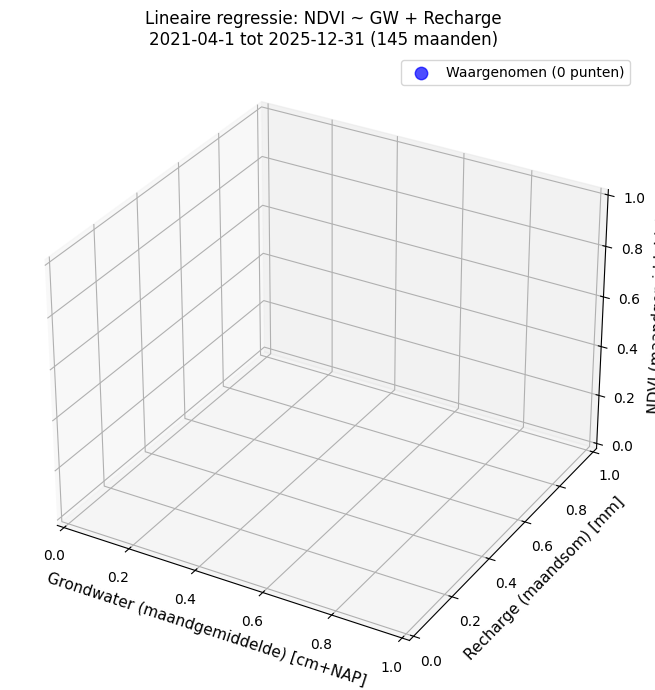

In [16]:
# ================================
# 1) OLS Lineaire regressie NDVI ~ GW + Recharge
# ================================

# Verwijder rijen met NaN of inf in de regressie-variabelen
regression_vars = ["gw_month", "recharge_month", "ndvi_month"]
df_reg = df_month.copy()
df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna(subset=regression_vars)

# Voeg interpolatiekolommen opnieuw toe indien nodig
for col in ["ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]:
    if col not in df_reg.columns and col in df_month.columns:
        df_reg[col] = df_month[col]
    elif col not in df_reg.columns:
        df_reg[col] = False

X = df_reg[["gw_month", "recharge_month"]]     # Onafhankelijke variabelen
X = sm.add_constant(X)         # Voeg intercept toe
y = df_reg["ndvi_month"]     # Afhankelijke variabele

ols_model = sm.OLS(y, X).fit()

print("\n===============================================")
print("OLS LINEAIRE REGRESSIE RESULTATEN (NDVI ~ GW + Recharge)")
print("===============================================")
print(ols_model.summary())

# ================================
# 3D Scatterplot + regressievlak
# ================================
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

is_obs = ~(df_reg["ndvi_interpolated"] | df_reg["recharge_interpolated"] | df_reg["gw_interpolated"])

ax.scatter(df_reg.loc[is_obs, "gw_month"], df_reg.loc[is_obs, "recharge_month"], df_reg.loc[is_obs, "ndvi_month"],
           label=f"Waargenomen ({is_obs.sum()} punten)", marker="o", s=80, alpha=0.7, color="blue")

ax.set_xlabel("Grondwater (maandgemiddelde) [cm+NAP]", fontsize=11)
ax.set_ylabel("Recharge (maandsom) [mm]", fontsize=11)
ax.set_zlabel("NDVI (maandgemiddelde)", fontsize=11)
ax.set_title(f"Lineaire regressie: NDVI ~ GW + Recharge\n{NDVI_START_DATE} tot {NDVI_END_DATE} ({len(df_reg)} maanden)", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


### ARDL(1,1) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     117.5
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.09e-26
Time:                        00:38:10   Log-Likelihood:                 154.20
No. Observations:                  56   AIC:                            -296.4
Df Residuals:                      50   BIC:                            -284.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1688      0.091      1.848      0.071      -0.015       0.352
gw_month          -0.0169      0.121     -0.139      0.890      -0.260       0.227
recharge_month     0.1859      0.112      1.660      0.103      -0.039       0.411
gw_lag1            0.0622      0.117      0.532      0.597      -0.173       0.297
recharge_lag1     -0.3049      0.114     -2.674      0.010      -0.534      -0.076
ndvi_lag1          0.8805      0.041     21.676      0.000       0.799       0.962
==============================================================================
Omnibus:                        8.406   Durbin-Watson:                   1.666
Prob(Omnibus):                  0.015   Jarque-Bera (JB):               10.655
Skew:                           0.514   Prob(JB):                      0.00486
Kurtosis:                       4.873   Cond. No.                         369.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

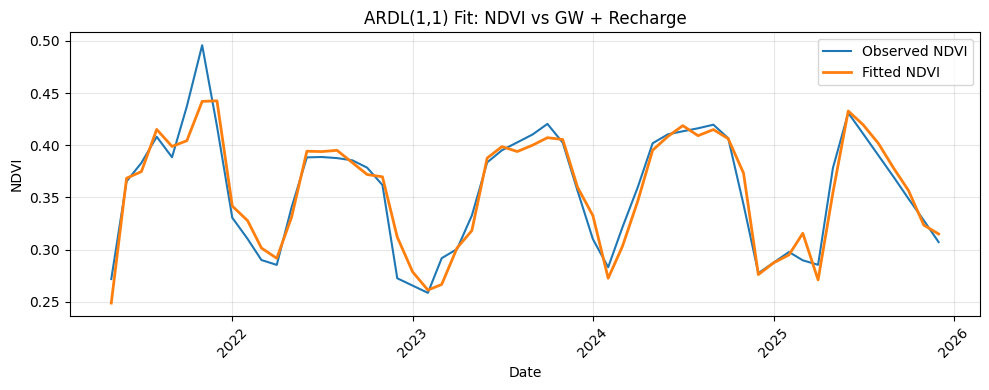

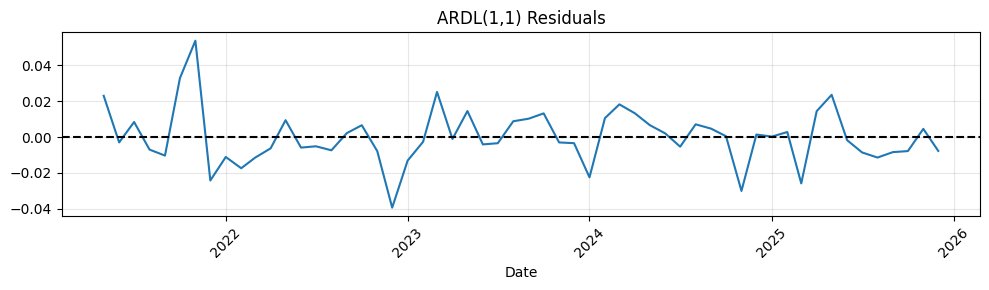

### ARDL(2,2) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     127.1
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           9.33e-29
Time:                        00:38:10   Log-Likelihood:                 166.15
No. Observations:                  56   AIC:                            -316.3
Df Residuals:                      48   BIC:                            -300.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1009      0.077      1.314      0.195      -0.054       0.255
gw_month          -0.0824      0.102     -0.810      0.422      -0.287       0.122
recharge_month     0.0883      0.052      1.706      0.094      -0.016       0.192
gw_lag1            0.1092      0.147      0.744      0.461      -0.186       0.404
gw_lag2           -0.0123      0.094     -0.131      0.896      -0.201       0.177
recharge_lag1     -0.0135      0.016     -0.850      0.400      -0.045       0.018
recharge_lag2     -0.1153      0.051     -2.258      0.029      -0.218      -0.013
ndvi_lag1          1.4003      0.108     12.931      0.000       1.183       1.618
ndvi_lag2         -0.5684      0.113     -5.045      0.000      -0.795      -0.342
==============================================================================
Omnibus:                        2.280   Durbin-Watson:                   2.250
Prob(Omnibus):                  0.320   Jarque-Bera (JB):                1.444
Skew:                           0.227   Prob(JB):                        0.486
Kurtosis:                       3.642   Cond. No.                     4.60e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.24e-33. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
```

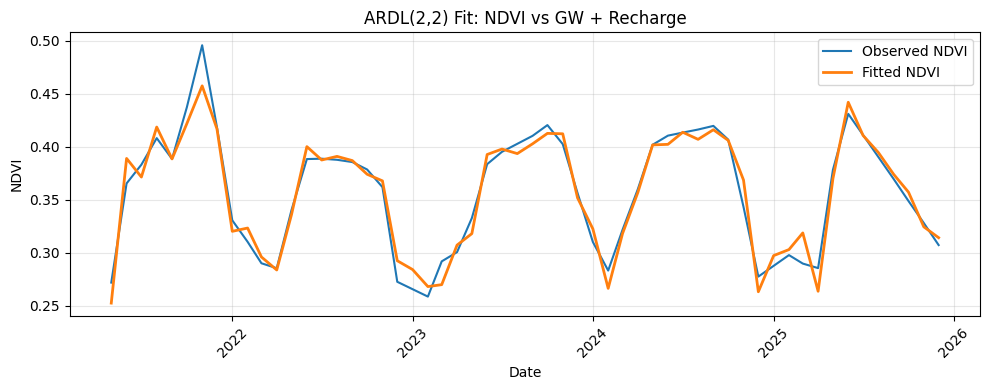

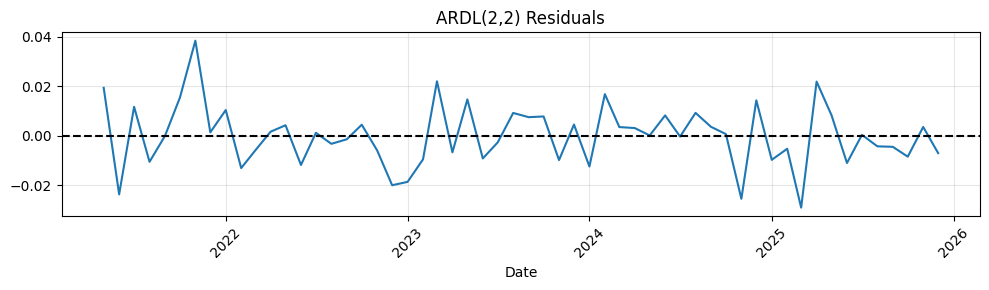

### ARDL(3,3) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     93.37
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.10e-26
Time:                        00:38:10   Log-Likelihood:                 169.16
No. Observations:                  56   AIC:                            -316.3
Df Residuals:                      45   BIC:                            -294.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1648      0.081      2.027      0.049       0.001       0.329
gw_month           0.0008      0.107      0.007      0.994      -0.214       0.215
recharge_month     0.0092      0.063      0.146      0.884      -0.117       0.135
gw_lag1           -0.0350      0.168     -0.208      0.836      -0.374       0.304
gw_lag2            0.0359      0.173      0.207      0.837      -0.313       0.385
gw_lag3            0.0380      0.091      0.418      0.678      -0.145       0.221
recharge_lag1      0.0375      0.030      1.238      0.222      -0.024       0.099
recharge_lag2      0.0658      0.096      0.687      0.496      -0.127       0.259
recharge_lag3     -0.1772      0.091     -1.956      0.057      -0.360       0.005
ndvi_lag1          1.4272      0.150      9.483      0.000       1.124       1.730
ndvi_lag2         -0.6783      0.272     -2.493      0.016      -1.226      -0.130
ndvi_lag3          0.0963      0.154      0.626      0.535      -0.214       0.406
==============================================================================
Omnibus:                        0.926   Durbin-Watson:                   2.158
Prob(Omnibus):                  0.630   Jarque-Bera (JB):                0.314
Skew:                          -0.001   Prob(JB):                        0.855
Kurtosis:                       3.367   Cond. No.                     6.48e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.15e-33. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
```

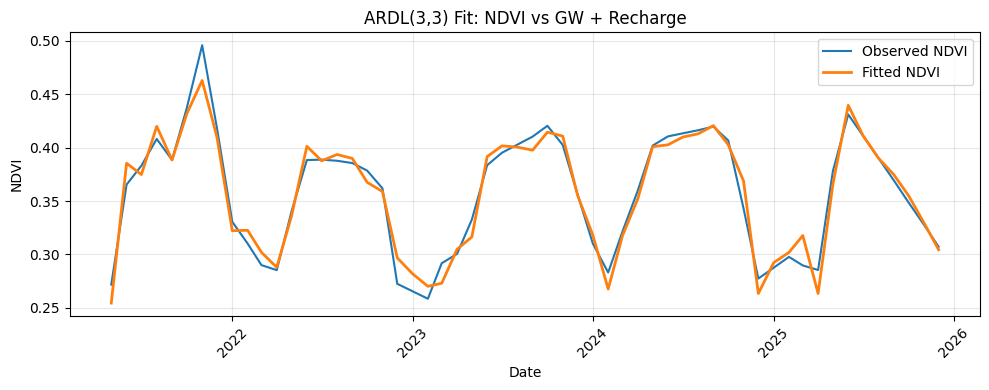

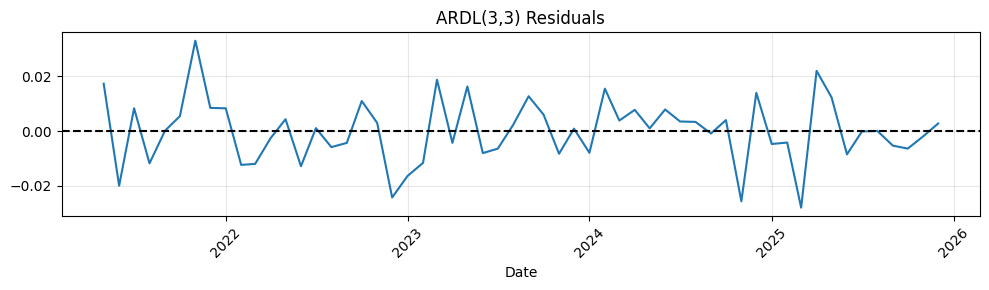

In [17]:
# ================================
# ARDL Models NDVI ~ GW + Recharge
# ================================

results = []
metrics = []

for p in [1, 2, 3]:
    q = p  # ARDL(p,p)

    # Create lagged dataframe
    df_lagged = df_month.copy()

    # NDVI lags
    for i in range(1, p+1):
        df_lagged[f"ndvi_lag{i}"] = df_lagged["ndvi_month"].shift(i)

    # GW lags
    for j in range(1, q+1):
        df_lagged[f"gw_lag{j}"] = df_lagged["gw_month"].shift(j)

    # Recharge lags
    for k in range(1, q+1):
        df_lagged[f"recharge_lag{k}"] = df_lagged["recharge_month"].shift(k)

    # Drop missing rows
    df_lagged = df_lagged.dropna()

    # Build X and y
    lag_cols = ["gw_month", "recharge_month"] + \
               [f"gw_lag{j}" for j in range(1, q+1)] + \
               [f"recharge_lag{k}" for k in range(1, q+1)] + \
               [f"ndvi_lag{i}" for i in range(1, p+1)]
    X = sm.add_constant(df_lagged[lag_cols])
    y = df_lagged["ndvi_month"]

    # Fit model
    model = sm.OLS(y, X).fit()
    results.append((p, q, model))

    # Print summary
    summary_text = model.summary().as_text()
    display(Markdown(f"### ARDL({p},{q}) Summary\n```\n{summary_text}\n```"))

    # Store metrics
    metrics.append({
        "Model": f"ARDL({p},{q})",
        "R²": round(model.rsquared, 3),
        "Adj R²": round(model.rsquared_adj, 3),
        "AIC": round(model.aic, 2),
        "BIC": round(model.bic, 2)
    })

    # Plot fitted vs actual (x-as = datum, alleen de juiste NDVI subset tonen)
    ardl_dates = df_lagged["date"].values if "date" in df_lagged.columns else df_lagged.index
    observed_ndvi = df_lagged["ndvi_month"].values
    plt.figure(figsize=(10, 4))
    plt.plot(ardl_dates, observed_ndvi, label="Observed NDVI")
    plt.plot(ardl_dates, model.fittedvalues, label="Fitted NDVI", linewidth=2)
    plt.title(f"ARDL({p},{q}) Fit: NDVI vs GW + Recharge")
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot residuals (x-as = datum)
    plt.figure(figsize=(10, 3))
    plt.plot(ardl_dates, model.resid)
    plt.axhline(0, color="black", linestyle="--")
    plt.title(f"ARDL({p},{q}) Residuals")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     480.3
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.84e-73
Time:                        00:38:10   Log-Likelihood:                 383.16
No. Observations:                 144   AIC:                            -758.3
Df Residuals:                     140   BIC:                            -746.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0447      0.051      0.

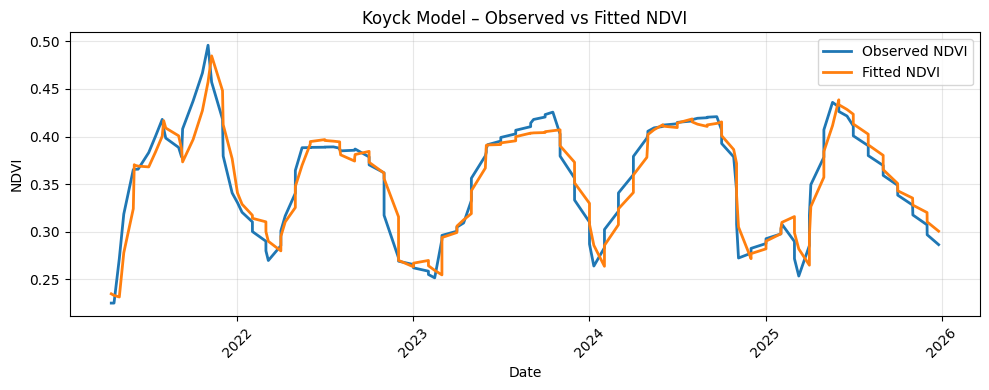

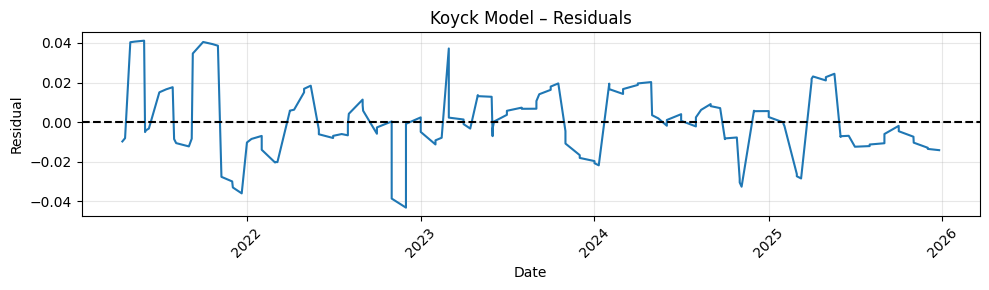

In [18]:
# ================================
# Koyck Transformation Model NDVI ~ GW + Recharge
# ================================

# Zorg dat de grondwaterdata ook NDVI_START_DATE en NDVI_END_DATE gebruikt (is al gedaan in eerdere cellen)
df_koyck = df_month.sort_index().copy()

# Create lag of NDVI: NDVI_{t-1}
df_koyck["ndvi_lag1"] = df_koyck["ndvi_month"].shift(1)

# First row has no lag → drop
df_koyck = df_koyck.dropna(subset=["ndvi_lag1", "recharge_month", "gw_month", "ndvi_month"])

# Define dependent and independent variables
y_k = df_koyck["ndvi_month"]                      # NDVI_t
X_k = df_koyck[["gw_month", "recharge_month", "ndvi_lag1"]]   # GW_t, Recharge_t and NDVI_{t-1}
X_k = sm.add_constant(X_k)                        # intercept

# OLS estimate (Koyck DLM)
koyck_model = sm.OLS(y_k, X_k).fit()
print(koyck_model.summary())

# Plot met x-as = datum, alleen de juiste NDVI subset tonen
koyck_dates = df_koyck["date"].values if "date" in df_koyck.columns else df_koyck.index
observed_ndvi = df_koyck["ndvi_month"].values
plt.figure(figsize=(10,4))
plt.plot(koyck_dates, observed_ndvi, label="Observed NDVI", linewidth=2)
plt.plot(koyck_dates, koyck_model.fittedvalues, label="Fitted NDVI", linewidth=2)
plt.title("Koyck Model – Observed vs Fitted NDVI")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(koyck_dates, koyck_model.resid)
plt.axhline(0, color="black", linestyle="--")
plt.title("Koyck Model – Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# ================================
# Model Comparison Summary
# ================================

summary_rows = []

# ============================================
# 1) LINEAR REGRESSION (OLS model)
# ============================================

n = len(ols_model.model.endog)
k = 1

y_ols = ols_model.model.endog
y_pred_ols = ols_model.fittedvalues
rss = np.sum((y_ols - y_pred_ols)**2)
tss = np.sum((y_ols - np.mean(y_ols))**2)

summary_rows.append({
    "Model": "Linear Regression",
    "R²": ols_model.rsquared,
    "Adj R²": ols_model.rsquared_adj,
    "Prob(F)": ols_model.f_pvalue,
    "AIC": ols_model.aic,
    "BIC": ols_model.bic
})

# ============================================
# 2) ARDL MODELS
# ============================================

for (p, q, model) in results:
    summary_rows.append({
        "Model": f"ARDL({p},{q})",
        "R²": model.rsquared,
        "Adj R²": model.rsquared_adj,
        "Prob(F)": model.f_pvalue,
        "AIC": model.aic,
        "BIC": model.bic
    })

# ============================================
# 3) KOYCK DLM
# ============================================

summary_rows.append({
    "Model": "Koyck Transformation",
    "R²": koyck_model.rsquared,
    "Adj R²": koyck_model.rsquared_adj,
    "Prob(F)": koyck_model.f_pvalue,
    "AIC": koyck_model.aic,
    "BIC": koyck_model.bic
})

# ============================================
# CREATE TABLE
# ============================================

summary_df = pd.DataFrame(summary_rows).round(4)
display(summary_df)

,Model,R²,Adj R²,Prob(F),AIC,BIC
0,Linear Regression,0.1688,0.1571,0.0,-436.7837,-427.8535
1,"ARDL(1,1)",0.9215,0.9137,0.0,-296.3907,-284.2386
2,"ARDL(2,2)",0.9488,0.9414,0.0,-316.3069,-300.1041
3,"ARDL(3,3)",0.9540,0.9438,0.0,-316.3119,-294.0330
4,Koyck Transformation,0.9114,0.9095,0.0,-758.3248,-746.4455


### Koyck Transformation Model Summary

                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     724.6
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           6.56e-75
Time:                        00:38:11   Log-Likelihood:                 383.08
No. Observations:                 144   AIC:                            -760.2
Df Residuals:                     141   BIC:                            -751.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0247      0.009      2.

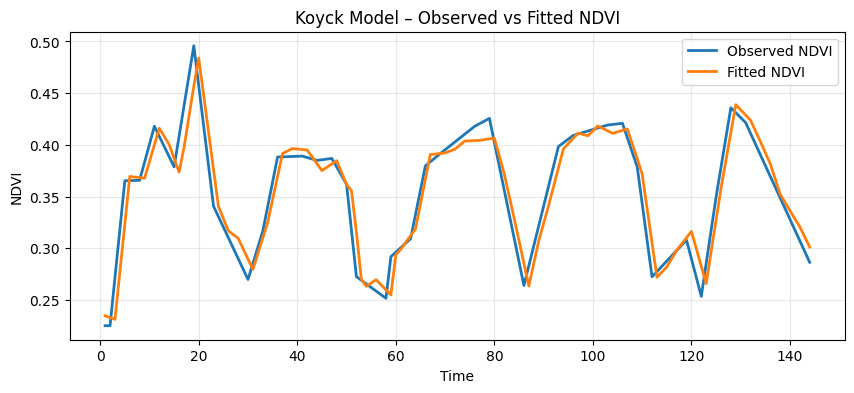

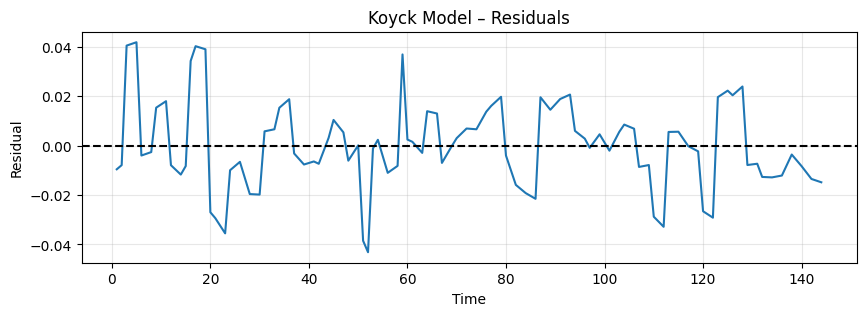

,Model,R²,Adj R²,Prob(F),AIC,BIC
0,Linear Regression,0.1688,0.1571,0.0,-436.7837,-427.8535
1,"ARDL(1,1)",0.9215,0.9137,0.0,-296.3907,-284.2386
2,"ARDL(2,2)",0.9488,0.9414,0.0,-316.3069,-300.1041
3,"ARDL(3,3)",0.9540,0.9438,0.0,-316.3119,-294.0330
4,Koyck Transformation,0.9113,0.9101,0.0,-760.1610,-751.2516


In [20]:
# ================================
# Koyck Transformation Model
# ================================

# Maak een kopie van de maandelijkse data, gesorteerd op tijd
df_koyck = df_month.sort_index().copy()

# Voeg NDVI lag 1 toe (NDVI_{t-1})
df_koyck["ndvi_lag1"] = df_koyck["ndvi_month"].shift(1)

# Drop eerste rij met NaN in lag of in NDVI/Recharge
df_koyck = df_koyck.dropna(subset=["ndvi_lag1", "recharge_month", "ndvi_month"])

# Definieer afhankelijke en onafhankelijke variabelen
y_k = df_koyck["ndvi_month"]                    # NDVI_t
X_k = df_koyck[["recharge_month", "ndvi_lag1"]] # huidige Recharge en NDVI_{t-1}
X_k = sm.add_constant(X_k)                      # voeg intercept toe

# Fit Koyck model (OLS)
koyck_model = sm.OLS(y_k, X_k).fit()
display(Markdown("### Koyck Transformation Model Summary"))
print(koyck_model.summary())

# Plot Observed vs Fitted
plt.figure(figsize=(10, 4))
plt.plot(df_koyck.index, y_k, label="Observed NDVI", linewidth=2)
plt.plot(df_koyck.index, koyck_model.fittedvalues, label="Fitted NDVI", linewidth=2)
plt.title("Koyck Model – Observed vs Fitted NDVI")
plt.xlabel("Time")
plt.ylabel("NDVI")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plot Residuals
plt.figure(figsize=(10, 3))
plt.plot(df_koyck.index, koyck_model.resid)
plt.axhline(0, color="black", linestyle="--")
plt.title("Koyck Model – Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.show()

# ================================
# Model Comparison Summary
# ================================

summary_rows = []

# ============================================
# 1) LINEAR REGRESSION (OLS model)
# ============================================

summary_rows.append({
    "Model": "Linear Regression",
    "R²": ols_model.rsquared,
    "Adj R²": ols_model.rsquared_adj,
    "Prob(F)": ols_model.f_pvalue,
    "AIC": ols_model.aic,
    "BIC": ols_model.bic
})

# ============================================
# 2) ARDL MODELS
# ============================================

for (p, q, model) in results:
    summary_rows.append({
        "Model": f"ARDL({p},{q})",
        "R²": model.rsquared,
        "Adj R²": model.rsquared_adj,
        "Prob(F)": model.f_pvalue,
        "AIC": model.aic,
        "BIC": model.bic
    })

# ============================================
# 3) KOYCK DLM
# ============================================

summary_rows.append({
    "Model": "Koyck Transformation",
    "R²": koyck_model.rsquared,
    "Adj R²": koyck_model.rsquared_adj,
    "Prob(F)": koyck_model.f_pvalue,
    "AIC": koyck_model.aic,
    "BIC": koyck_model.bic
})

# ============================================
# CREATE TABLE
# ============================================

summary_df = pd.DataFrame(summary_rows).round(4)
display(summary_df)

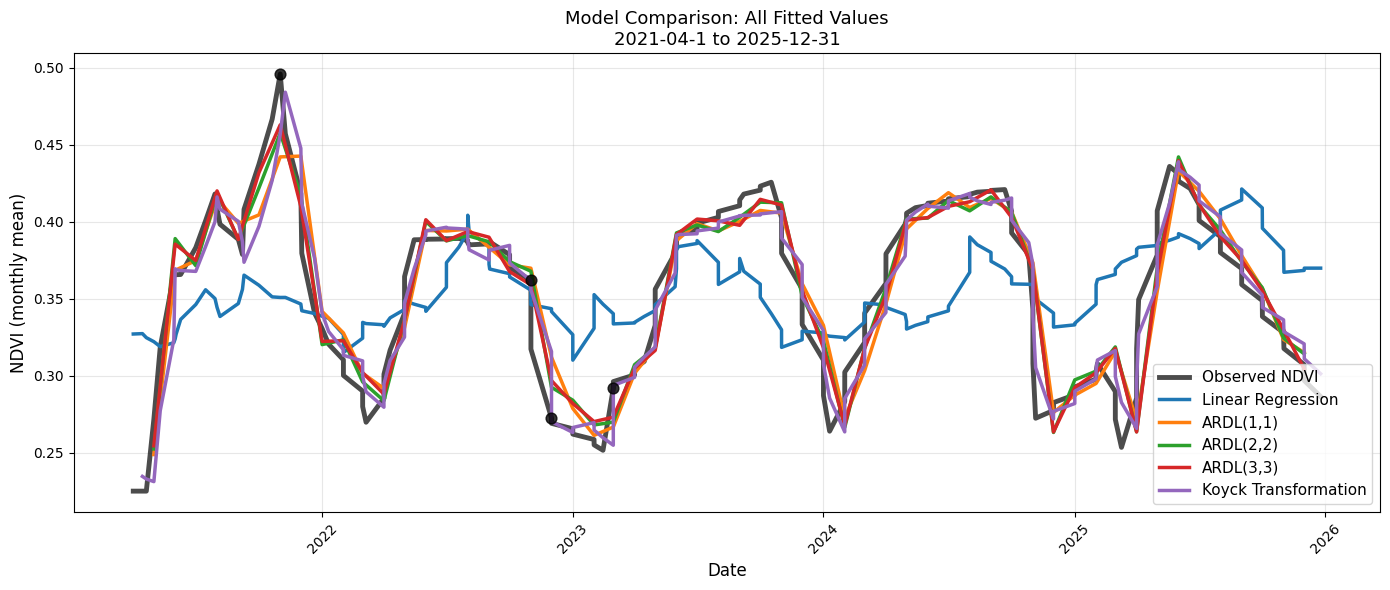

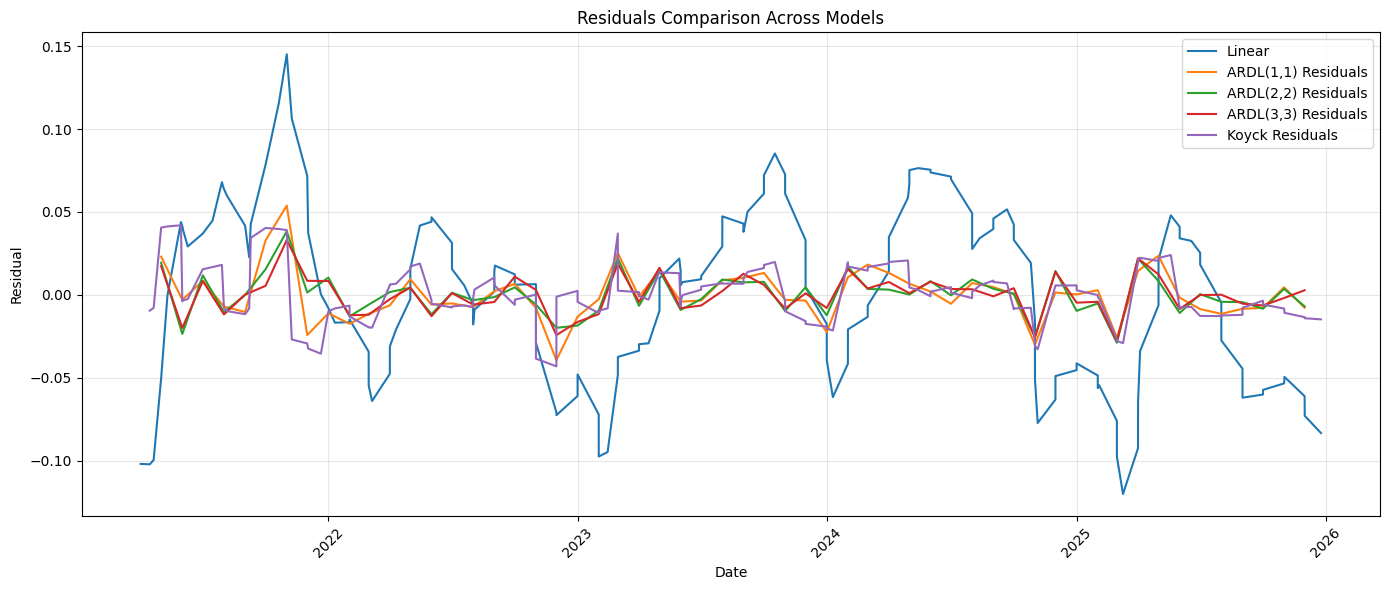

,Model,R²,Adj R²,Prob(F),F-statistic,AIC,BIC
0,Linear Regression,0.1688,0.1571,0.0,14.4149,-436.7837,-427.8535
1,"ARDL(1,1)",0.9215,0.9137,0.0,117.4629,-296.3907,-284.2386
2,"ARDL(2,2)",0.9488,0.9414,0.0,127.1114,-316.3069,-300.1041
3,"ARDL(3,3)",0.9540,0.9438,0.0,93.3684,-316.3119,-294.0330
4,Koyck Transformation,0.9113,0.9101,0.0,724.6200,-760.1610,-751.2516


In [21]:
# ================================
# COMBINED MODEL COMPARISON PLOT
# ================================

fig, ax = plt.subplots(figsize=(14, 6))

# Define colors for each model
colors = {
    'ols': '#1f77b4',           # Blue
    'ardl_1_1': '#ff7f0e',      # Orange
    'ardl_2_2': '#2ca02c',      # Green
    'ardl_3_3': '#d62728',      # Red
    'koyck': '#9467bd'          # Purple
}

# Voeg interpolatiekolommen toe indien nodig
for col in ["ndvi_interpolated", "recharge_interpolated"]:
    if col not in df_month.columns:
        df_month[col] = False

# Plot observed NDVI on full timeseries
is_obs_full = ~(df_month["ndvi_interpolated"] | df_month["recharge_interpolated"])
ax.plot(df_month["date"], df_month["ndvi_month"],
        color="black", linewidth=3.5, alpha=0.7, label="Observed NDVI", zorder=3)
ax.scatter(df_month.loc[is_obs_full, "date"], df_month.loc[is_obs_full, "ndvi_month"],
          marker="o", s=60, alpha=0.8, color="black", zorder=10)

# 1) Linear Regression (OLS)
# Get dates corresponding to OLS model observations using label-based indexing
ols_dates = df_month.loc[ols_model.fittedvalues.index, "date"].values
ax.plot(ols_dates, ols_model.fittedvalues.values, 
        linewidth=2.5, color=colors['ols'], label="Linear Regression", zorder=5)

# 2) ARDL Models
for idx, (p, q, model) in enumerate(results):
    model_key = f'ardl_{p}_{q}'
    # Get original indices from the model using label-based indexing
    ardl_indices = model.fittedvalues.index
    ardl_dates = df_month.loc[ardl_indices, "date"].values
    ax.plot(ardl_dates, model.fittedvalues.values, 
           linewidth=2.5, color=colors[model_key], label=f"ARDL({p},{q})", zorder=5)

# 3) Koyck Model
# Use label-based indexing instead of positional
koyck_dates = df_koyck.loc[koyck_model.fittedvalues.index, "date"].values
ax.plot(koyck_dates, koyck_model.fittedvalues.values, 
       linewidth=2.5, color=colors['koyck'], label="Koyck Transformation", zorder=5)

# Format plot
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("NDVI (monthly mean)", fontsize=12)
ax.set_title(f"Model Comparison: All Fitted Values\n{NDVI_START_DATE} to {NDVI_END_DATE}", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- RESIDUALS COMPARISON ----------
plt.figure(figsize=(14,6))

# OLS residuals
ols_dates = df_month.loc[ols_model.resid.index, "date"].values
plt.plot(ols_dates, ols_model.resid.values, label="Linear", color=colors['ols'], linewidth=1.5)

# ARDL residuals
for p, q, model in results:
    key = f'ardl_{p}_{q}'
    res_dates = df_month.loc[model.resid.index, "date"].values
    plt.plot(res_dates, model.resid.values, label=f"ARDL({p},{q}) Residuals", color=colors[key], linewidth=1.5)

# Koyck residuals
koyck_res_dates = df_koyck.loc[koyck_model.resid.index, "date"].values
plt.plot(koyck_res_dates, koyck_model.resid.values, label="Koyck Residuals", color=colors['koyck'], linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Residuals Comparison Across Models")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# finally display summary table with F-statistic in requested order
def get_f_stat(model):
    try:
        return model.fvalue
    except AttributeError:
        return None

summary_rows_f = []
summary_rows_f.append({
    "Model": "Linear Regression",
    "R²": ols_model.rsquared,
    "Adj R²": ols_model.rsquared_adj,
    "Prob(F)": ols_model.f_pvalue,
    "F-statistic": get_f_stat(ols_model),
    "AIC": ols_model.aic,
    "BIC": ols_model.bic
})
for (p, q, model) in results:
    summary_rows_f.append({
        "Model": f"ARDL({p},{q})",
        "R²": model.rsquared,
        "Adj R²": model.rsquared_adj,
        "Prob(F)": model.f_pvalue,
        "F-statistic": get_f_stat(model),
        "AIC": model.aic,
        "BIC": model.bic
    })
summary_rows_f.append({
    "Model": "Koyck Transformation",
    "R²": koyck_model.rsquared,
    "Adj R²": koyck_model.rsquared_adj,
    "Prob(F)": koyck_model.f_pvalue,
    "F-statistic": get_f_stat(koyck_model),
    "AIC": koyck_model.aic,
    "BIC": koyck_model.bic
})
summary_df_f = pd.DataFrame(summary_rows_f)[["Model", "R²", "Adj R²", "Prob(F)", "F-statistic", "AIC", "BIC"]].round(4)
display(summary_df_f)

In [22]:
# ================================
# Controle: zijn alle modellen over dezelfde tijdsperiode uitgevoerd?
# ================================

def print_model_period(label, dates):
    print(f"{label}: {len(dates)} maanden, {dates.min().date()} t/m {dates.max().date()}")

# 1. OLS model
ols_idx = ols_model.fittedvalues.index
ols_dates = df_month.loc[ols_idx, "date"] if hasattr(ols_model, 'fittedvalues') else pd.Series(dtype='datetime64[ns]')
print_model_period("OLS", ols_dates)

# 2. ARDL modellen
for p, q, model in results:
    idx = model.fittedvalues.index
    dates = df_month.loc[idx, "date"] if hasattr(model, 'fittedvalues') else pd.Series(dtype='datetime64[ns]')
    print_model_period(f"ARDL({p},{q})", dates)

# 3. Koyck model
if 'koyck_model' in globals():
    koyck_idx = koyck_model.fittedvalues.index
    koyck_dates = df_koyck.loc[koyck_idx, "date"] if hasattr(koyck_model, 'fittedvalues') else pd.Series(dtype='datetime64[ns]')
    print_model_period("Koyck", koyck_dates)

# 4. Waargenomen NDVI (volledige tijdreeks)
print_model_period("Observed NDVI (volledig)", df_month["date"])

# 5. Toon verschillen in periodes
print("\nVergelijking van datums per model:")
model_dates = {
    "OLS": set(ols_dates),
    **{f"ARDL({p},{q})": set(df_month.loc[model.fittedvalues.index, "date"]) for p, q, model in results},
    "Koyck": set(koyck_dates) if 'koyck_dates' in locals() else set(),
    "Observed": set(df_month["date"]),
}
all_dates = set.union(*model_dates.values())
for name, dates in model_dates.items():
    missing = sorted(all_dates - dates)
    if missing:
        print(f"{name} mist {len(missing)} maanden: {[d.strftime('%Y-%m-%d') for d in missing]}")
    else:
        print(f"{name} bevat alle maanden.")

OLS: 145 maanden, 2021-04-01 t/m 2025-12-25
ARDL(1,1): 56 maanden, 2021-05-01 t/m 2025-12-01
ARDL(2,2): 56 maanden, 2021-05-01 t/m 2025-12-01
ARDL(3,3): 56 maanden, 2021-05-01 t/m 2025-12-01
Koyck: 144 maanden, 2021-04-14 t/m 2025-12-25
Observed NDVI (volledig): 145 maanden, 2021-04-01 t/m 2025-12-25

Vergelijking van datums per model:
OLS bevat alle maanden.
ARDL(1,1) mist 89 maanden: ['2021-04-01', '2021-04-14', '2021-04-20', '2021-05-10', '2021-05-30', '2021-06-02', '2021-06-09', '2021-07-15', '2021-07-29', '2021-08-05', '2021-09-07', '2021-09-09', '2021-10-20', '2021-11-08', '2021-12-02', '2021-12-21', '2022-01-10', '2022-02-01', '2022-03-01', '2022-03-06', '2022-04-01', '2022-04-10', '2022-05-01', '2022-05-15', '2022-06-01', '2022-07-01', '2022-07-19', '2022-08-01', '2022-08-03', '2022-09-01', '2022-09-02', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01', '2023-02-14', '2023-03-01', '2023-04-01', '2023-04-15', '2023-05-01', '2023-05-30', '2023-06-01', '2023-06